# 11 — Consolidated results and original-paper comparison

Following Code 07, load saved results, verify monthly factor returns, compare train/validation/test Sharpe and rankings, examine risk and correlations, and consolidate rolling, regime, and seed diagnostics. No models are retrained.

**Questions:** How close are the models to the original paper? Does Transformer improve on matched LSTM? Are differences consistent across seeds, windows, and economic regimes? Do returns or volatility explain performance gaps?

**Process:** validate inputs → compare all six models with paper → rank models → examine risk and co-movement → review seed, rolling, and regime comparisons → answer questions and save artifacts.

Paper benchmarks: [Chen, Pelger, and Zhu, Table I](https://arxiv.org/pdf/1904.00745). Our new models use the shortened 16/4/48 schedule and nine seeds. Historical replication and paper benchmarks use different procedures. Monthly Sharpe uses ddof=0; annualized Sharpe multiplies by √12. No published Transformer result exists. This is a descriptive consolidation of previously examined test results.


### Monthly Sharpe: train, validation, and test

| model | train | validation | test |
| --- | --- | --- | --- |
| LS | 2.029 | 0.770 | 0.406 |
| EN | 1.125 | 1.038 | 0.412 |
| FFN | 0.660 | 0.852 | 0.570 |
| GAN–LSTM original | 2.224 | 1.185 | 0.612 |
| GAN–LSTM reduced schedule | 1.308 | 0.750 | 0.459 |
| GAN–Transformer reduced schedule | 1.049 | 0.589 | 0.304 |
| LS (paper) | 1.800 | 0.580 | 0.420 |
| EN (paper) | 1.370 | 1.150 | 0.500 |
| FFN (paper) | 0.450 | 0.420 | 0.440 |
| GAN–LSTM (paper) | 2.680 | 1.430 | 0.750 |

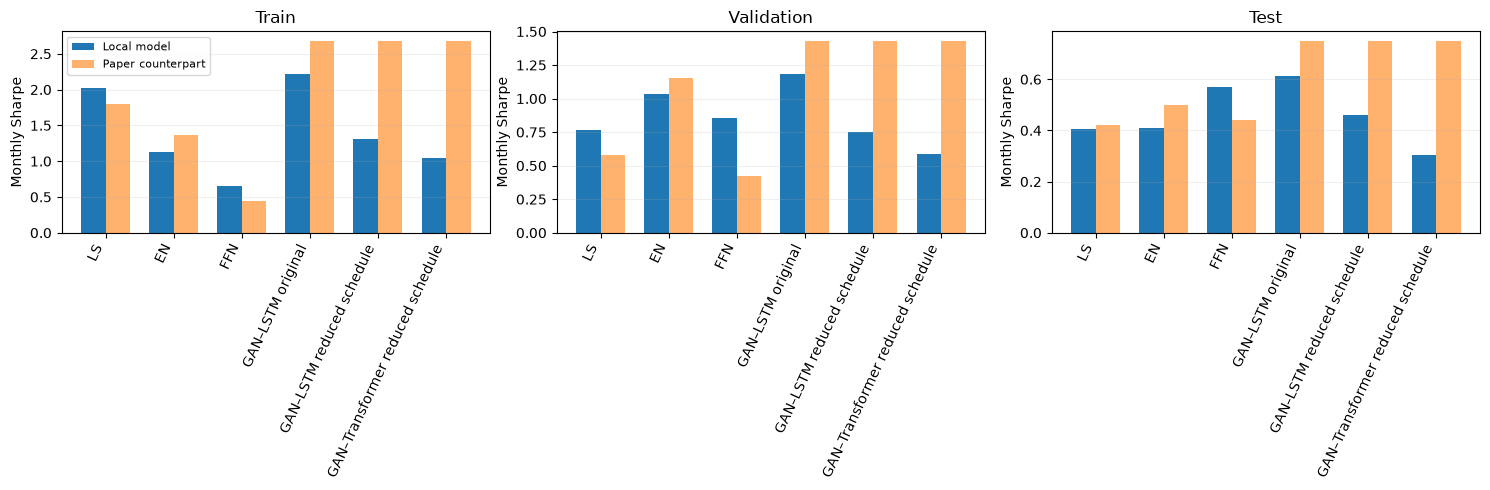

### Rankings: 1 is highest Sharpe

| model | train | validation | test |
| --- | --- | --- | --- |
| LS | 2.000 | 4.000 | 5.000 |
| EN | 4.000 | 2.000 | 4.000 |
| FFN | 6.000 | 3.000 | 2.000 |
| GAN–LSTM original | 1.000 | 1.000 | 1.000 |
| GAN–LSTM reduced schedule | 3.000 | 5.000 | 3.000 |
| GAN–Transformer reduced schedule | 5.000 | 6.000 | 6.000 |

### Return and risk

| model | mean_monthly | annualized_volatility | monthly_sharpe | annualized_sharpe | maximum_drawdown | worst_month | positive_month_fraction | terminal_wealth |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| LS | 0.003 | 0.030 | 0.406 | 1.408 | -0.083 | -0.053 | 0.733 | 2.797 |
| EN | 0.006 | 0.051 | 0.412 | 1.426 | -0.147 | -0.088 | 0.757 | 5.829 |
| FFN | 0.015 | 0.091 | 0.570 | 1.973 | -0.085 | -0.076 | 0.800 | 79.982 |
| GAN–LSTM original | 0.007 | 0.040 | 0.612 | 2.120 | -0.065 | -0.052 | 0.823 | 7.944 |
| GAN–LSTM reduced schedule | 0.005 | 0.039 | 0.459 | 1.591 | -0.111 | -0.079 | 0.730 | 4.553 |
| GAN–Transformer reduced schedule | 0.004 | 0.048 | 0.304 | 1.055 | -0.154 | -0.082 | 0.680 | 3.450 |

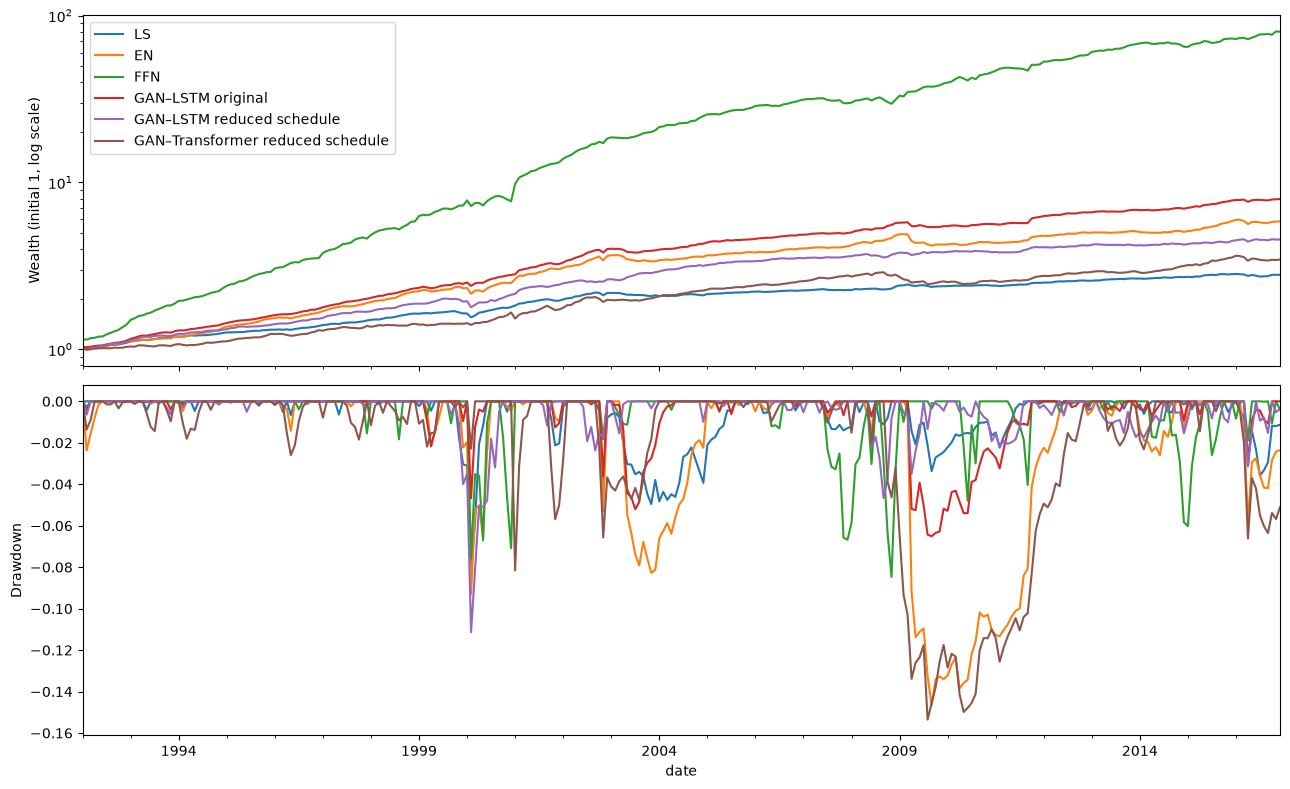

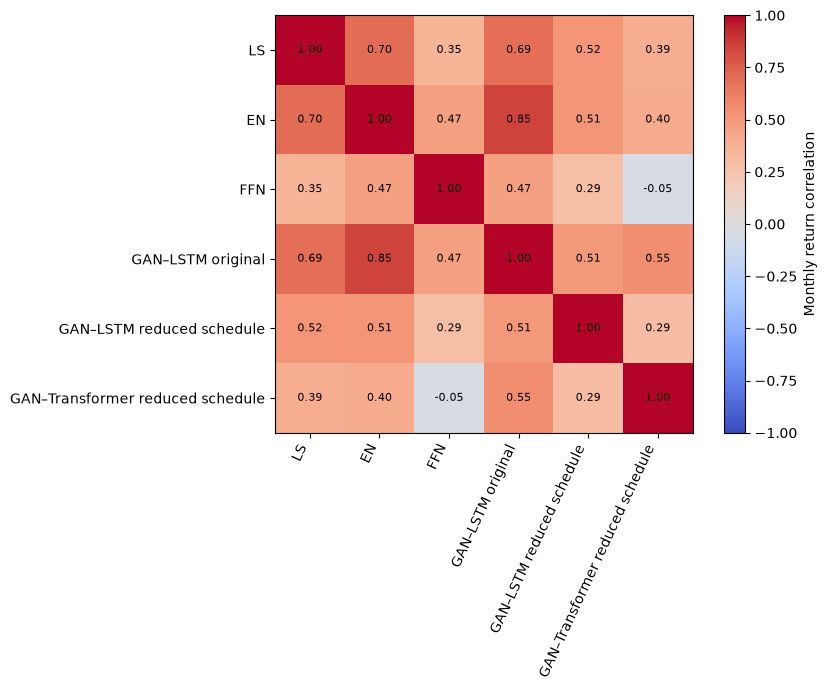

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd()
if not (ROOT / 'results').exists(): ROOT = ROOT.parent
assert (ROOT / 'results').exists()
def mdtable(df):
    d=df.copy()
    for col in d.select_dtypes(include='number'): d[col]=d[col].map(lambda x: f'{x:.3f}')
    return '| '+' | '.join(map(str,d.columns))+' |\n| '+' | '.join(['---']*len(d.columns))+' |\n'+'\n'.join('| '+' | '.join(map(str,row))+' |' for row in d.itertuples(index=False,name=None))

import json,hashlib
OUT=ROOT/'results/consolidated_comparison'
for sub in ['tables','figures']: (OUT/sub).mkdir(parents=True,exist_ok=True)
R09=ROOT/'results/rolling_oos_reduced_schedule'
paths=[R09/'tables/all_models_vs_paper_monthly_sharpe.csv',R09/'factors/all_model_test_factor_returns.csv']
assert all(p.exists() for p in paths)
comparison=pd.read_csv(paths[0]);returns=pd.read_csv(paths[1],parse_dates=['date']).set_index('date')
assert returns.shape==(300,6) and returns.index.is_unique
assert returns.index.equals(pd.date_range('1992-01-01','2016-12-01',freq='MS'))
assert np.isfinite(returns.to_numpy()).all() and (returns.to_numpy()>-1).all()
local=comparison[comparison.source=='Our saved model returns'].set_index('model')
sharpe=returns.mean()/returns.std(ddof=0)
np.testing.assert_allclose(sharpe,local.loc[returns.columns,'test'],rtol=1e-10,atol=1e-10)
(OUT/'input_manifest.json').write_text(json.dumps({str(p.relative_to(ROOT)):hashlib.sha256(p.read_bytes()).hexdigest() for p in paths},indent=2))
comparison.to_csv(OUT/'tables/all_models_vs_paper.csv',index=False)
display(Markdown('### Monthly Sharpe: train, validation, and test\n\n'+mdtable(comparison[['model','train','validation','test']])))
fig,axes=plt.subplots(1,3,figsize=(15,5))
for ax,split in zip(axes,['train','validation','test']):
    values=local[split];x=np.arange(6)
    benchmark=[{'train':1.8,'validation':.58,'test':.42}[split],{'train':1.37,'validation':1.15,'test':.5}[split],{'train':.45,'validation':.42,'test':.44}[split]]+[{'train':2.68,'validation':1.43,'test':.75}[split]]*3
    ax.bar(x-.18,values,width=.36,label='Local model');ax.bar(x+.18,benchmark,width=.36,alpha=.6,label='Paper counterpart')
    ax.set_xticks(x,local.index,rotation=65,ha='right');ax.set_title(split.title());ax.set_ylabel('Monthly Sharpe');ax.grid(axis='y',alpha=.2)
axes[0].legend(fontsize=8);fig.tight_layout();fig.savefig(OUT/'figures/all_models_vs_paper.png',dpi=160);plt.show()
ranking=local[['train','validation','test']].rank(ascending=False,method='min').astype(int).reset_index()
ranking.to_csv(OUT/'tables/model_rankings.csv',index=False);display(Markdown('### Rankings: 1 is highest Sharpe\n\n'+mdtable(ranking)))
wealth=(1+returns).cumprod();drawdown=wealth/wealth.cummax().clip(lower=1)-1
risk=pd.DataFrame({'model':returns.columns,'mean_monthly':returns.mean().values,'annualized_volatility':(returns.std(ddof=0)*np.sqrt(12)).values,'monthly_sharpe':sharpe.values,'annualized_sharpe':(sharpe*np.sqrt(12)).values,'maximum_drawdown':drawdown.min().values,'worst_month':returns.min().values,'positive_month_fraction':(returns>0).mean().values,'terminal_wealth':wealth.iloc[-1].values})
risk.to_csv(OUT/'tables/all_models_test_risk.csv',index=False);display(Markdown('### Return and risk\n\n'+mdtable(risk)))
fig,axes=plt.subplots(2,1,figsize=(13,8),sharex=True);wealth.plot(ax=axes[0]);axes[0].set_yscale('log');axes[0].set_ylabel('Wealth (initial 1, log scale)');drawdown.plot(ax=axes[1],legend=False);axes[1].set_ylabel('Drawdown');fig.tight_layout();fig.savefig(OUT/'figures/wealth_and_drawdown.png',dpi=160);plt.show()
corr=returns.corr();corr.to_csv(OUT/'tables/test_return_correlations.csv')
fig,ax=plt.subplots(figsize=(9,7));im=ax.imshow(corr,vmin=-1,vmax=1,cmap='coolwarm');ax.set_xticks(range(6),returns.columns,rotation=65,ha='right');ax.set_yticks(range(6),returns.columns)
for i in range(6):
    for j in range(6):ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=8)
fig.colorbar(im,ax=ax,label='Monthly return correlation');fig.tight_layout();fig.savefig(OUT/'figures/correlations.png',dpi=160);plt.show()


## Interpretation of the consolidated comparison

Paper GAN benchmarks contextualize all GAN variants; they do not isolate architecture effects. Compare the two reduced-budget models directly to assess the new experiment. Historical Code 07 is an earlier replication with different conventions.

Wealth and drawdown use the saved factor-return definition and exclude trading costs. Initial wealth is one before the first month. Return correlations describe co-movement, not identical holdings or guaranteed diversification. Code 11 does not recompute characteristic importance, pricing-error tests, or author regime returns, which require separate model-level inputs.


## Consolidated diagnostic from 08_reduced_schedule_comparison

The following reproduces its expanded comparison using the same saved inputs and units.

### Individual seeds versus the ensemble

| architecture | split | count | mean | std | min | median | max |
| --- | --- | --- | --- | --- | --- | --- | --- |
| LSTM | test | 9.000 | 0.178 | 0.116 | 0.045 | 0.199 | 0.412 |
| LSTM | train | 9.000 | 0.668 | 0.109 | 0.486 | 0.649 | 0.802 |
| LSTM | validation | 9.000 | 0.261 | 0.135 | 0.144 | 0.228 | 0.515 |
| Transformer | test | 9.000 | 0.146 | 0.129 | -0.006 | 0.118 | 0.356 |
| Transformer | train | 9.000 | 0.536 | 0.123 | 0.376 | 0.518 | 0.737 |
| Transformer | validation | 9.000 | 0.272 | 0.222 | 0.018 | 0.206 | 0.645 |

### Published GAN benchmark: absolute monthly Sharpe gaps

| model | train | validation | test | train_gap_to_paper | validation_gap_to_paper | test_gap_to_paper |
| --- | --- | --- | --- | --- | --- | --- |
| Reduced schedule LSTM | 1.308 | 0.750 | 0.459 | -1.372 | -0.680 | -0.291 |
| Reduced schedule Transformer | 1.049 | 0.589 | 0.304 | -1.631 | -0.841 | -0.446 |
| Historical Code 07 GAN–LSTM | 2.224 | 1.185 | 0.612 | -0.456 | -0.245 | -0.138 |

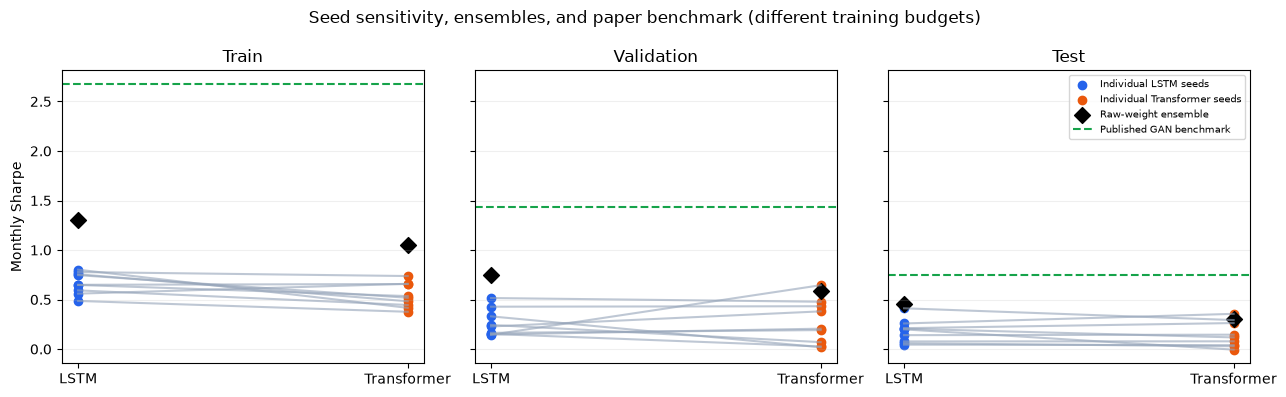

### How to interpret this comparison

The Transformer exceeds its same-numbered LSTM seed on test Sharpe in **4 of 9 seed pairs**. Pairing seed numbers is a descriptive convenience: different architectures consume random draws differently. Seed dispersion measures initialization sensitivity on one market history, not independent market evidence or a confidence interval.

The ensemble Sharpe is calculated from averaged raw stock weights, followed by monthly gross normalization. It is **not the average of the nine individual Sharpe ratios**. Diversification across members can improve the ensemble even when individual members perform weakly.

The new LSTM test Sharpe is 0.459; Transformer is 0.304; historical Code 07 is 0.612; published GAN is 0.750. Historical and paper comparisons mix training budgets and implementation conventions. Only the two new architectures share this experiment's budget.

The reduced 16/4/48 schedule and four-epoch checkpoint warm-up differ from the author schedule. A gap to the paper can reflect training, implementation, or tuning differences; this experiment does not identify their separate effects. Lower training Sharpe is consistent with incomplete optimization, but is not proof of its cause.

**Connection to Code 09:** fixed saved ensemble returns become rolling diagnostics. **Connection to Code 10:** the same returns are grouped by economic conditions; neither analysis retrains or selects the model.


1452

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd()
if not (ROOT / 'results').exists(): ROOT = ROOT.parent
assert (ROOT / 'results').exists()
def mdtable(df):
    d=df.copy()
    for col in d.select_dtypes(include='number'): d[col]=d[col].map(lambda x: f'{x:.3f}')
    return '| '+' | '.join(map(str,d.columns))+' |\n| '+' | '.join(['---']*len(d.columns))+' |\n'+'\n'.join('| '+' | '.join(map(str,row))+' |' for row in d.itertuples(index=False,name=None))

out=ROOT/'results/paper_matched_reduced_schedule'
members=pd.read_csv(out/'tables/member_performance.csv')
bench=pd.read_csv(out/'tables/full_short_paper_sharpe_comparison.csv').set_index('model')
seed_summary=members.groupby(['architecture','split']).monthly_sharpe.agg(['count','mean','std','min','median','max']).reset_index()
seed_summary.to_csv(out/'tables/explanation_seed_comparison.csv',index=False)
display(Markdown('### Individual seeds versus the ensemble\n\n'+mdtable(seed_summary)))
paired=members.pivot(index=['seed','split'],columns='architecture',values='monthly_sharpe').reset_index()
paired['transformer_minus_lstm']=paired.Transformer-paired.LSTM
paired.to_csv(out/'tables/explanation_paired_seed_gaps.csv',index=False)
gaps=bench.loc[['Reduced schedule LSTM','Reduced schedule Transformer','Historical Code 07 GAN–LSTM']].copy()
for split in ['train','validation','test']: gaps[split+'_gap_to_paper']=gaps[split]-bench.loc['Paper GAN–LSTM',split]
gaps.reset_index().to_csv(out/'tables/explanation_paper_gaps.csv',index=False)
display(Markdown('### Published GAN benchmark: absolute monthly Sharpe gaps\n\n'+mdtable(gaps.reset_index())))
fig,axes=plt.subplots(1,3,figsize=(13,4),sharey=True)
for ax,split in zip(axes,['train','validation','test']):
    sub=paired[paired.split==split]
    for row in sub.itertuples(): ax.plot([0,1],[row.LSTM,row.Transformer],color='#94a3b8',alpha=.6)
    ax.scatter(np.zeros(len(sub)),sub.LSTM,color='#2563eb',label='Individual LSTM seeds')
    ax.scatter(np.ones(len(sub)),sub.Transformer,color='#ea580c',label='Individual Transformer seeds')
    ax.scatter([0,1],[bench.loc['Reduced schedule LSTM',split],bench.loc['Reduced schedule Transformer',split]],marker='D',s=65,color='black',label='Raw-weight ensemble')
    ax.axhline(bench.loc['Paper GAN–LSTM',split],color='#16a34a',linestyle='--',label='Published GAN benchmark')
    ax.set_xticks([0,1],['LSTM','Transformer']);ax.set_title(split.title());ax.grid(axis='y',alpha=.2)
axes[0].set_ylabel('Monthly Sharpe');axes[-1].legend(fontsize=7)
fig.suptitle('Seed sensitivity, ensembles, and paper benchmark (different training budgets)')
fig.tight_layout();fig.savefig(out/'figures/explanation_seed_vs_ensemble.png',dpi=160);plt.show()
test=paired[paired.split=='test'];wins=int((test.transformer_minus_lstm>0).sum())
text=f'''### How to interpret this comparison

The Transformer exceeds its same-numbered LSTM seed on test Sharpe in **{wins} of 9 seed pairs**. Pairing seed numbers is a descriptive convenience: different architectures consume random draws differently. Seed dispersion measures initialization sensitivity on one market history, not independent market evidence or a confidence interval.

The ensemble Sharpe is calculated from averaged raw stock weights, followed by monthly gross normalization. It is **not the average of the nine individual Sharpe ratios**. Diversification across members can improve the ensemble even when individual members perform weakly.

The new LSTM test Sharpe is {bench.loc['Reduced schedule LSTM','test']:.3f}; Transformer is {bench.loc['Reduced schedule Transformer','test']:.3f}; historical Code 07 is {bench.loc['Historical Code 07 GAN–LSTM','test']:.3f}; published GAN is {bench.loc['Paper GAN–LSTM','test']:.3f}. Historical and paper comparisons mix training budgets and implementation conventions. Only the two new architectures share this experiment's budget.

The reduced 16/4/48 schedule and four-epoch checkpoint warm-up differ from the author schedule. A gap to the paper can reflect training, implementation, or tuning differences; this experiment does not identify their separate effects. Lower training Sharpe is consistent with incomplete optimization, but is not proof of its cause.

**Connection to Code 09:** fixed saved ensemble returns become rolling diagnostics. **Connection to Code 10:** the same returns are grouped by economic conditions; neither analysis retrains or selects the model.
'''
display(Markdown(text));(out/'explanation_addendum.md').write_text(text)


## Consolidated diagnostic from 09_reduced_schedule_oos

The following reproduces its expanded comparison using the same saved inputs and units.

### Rolling Sharpe distribution (annualized)

| window_months | model | windows | mean | median | minimum | maximum | monthly_equivalent_of_mean |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 36.000 | gan_lstm_matched | 265.000 | 1.992 | 1.406 | 0.222 | 4.245 | 0.575 |
| 36.000 | gan_transformer | 265.000 | 1.467 | 1.472 | -0.628 | 3.891 | 0.424 |
| 60.000 | gan_lstm_matched | 241.000 | 1.795 | 1.496 | 0.576 | 3.913 | 0.518 |
| 60.000 | gan_transformer | 241.000 | 1.228 | 1.284 | 0.003 | 3.099 | 0.355 |

### One Sharpe over the full test period

| model | months | monthly_sharpe | annualized_sharpe | annualized_volatility | maximum_drawdown |
| --- | --- | --- | --- | --- | --- |
| gan_lstm_matched | 300.000 | 0.459 | 1.591 | 0.039 | -0.111 |
| gan_transformer | 300.000 | 0.304 | 1.055 | 0.048 | -0.154 |

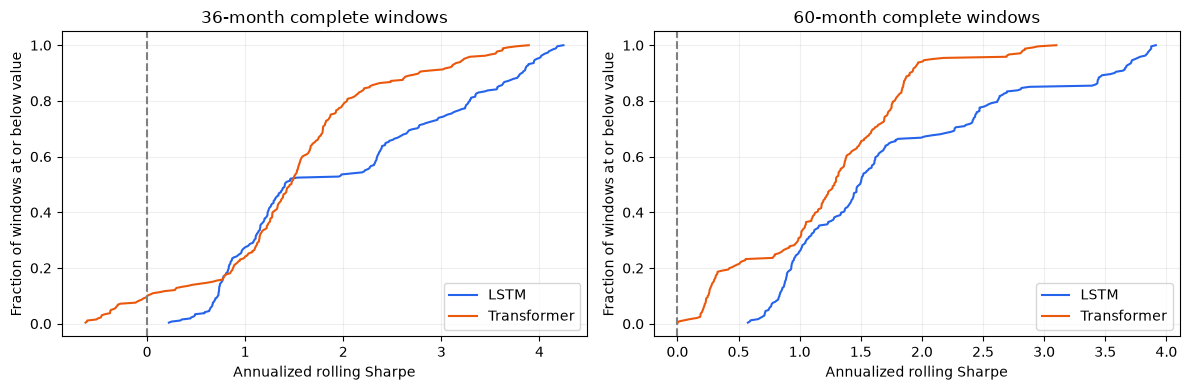

### Why rolling and full-period Sharpe differ

For each window, monthly Sharpe is mean monthly return divided by monthly standard deviation (ddof=0). Annualized Sharpe multiplies it by √12. A 36-month window contains the latest 36 monthly returns; a 60-month window contains the latest 60. The first complete endpoints are December 1994 and December 1996.

Averaging window Sharpe ratios is not the same calculation as dividing the full-period mean by its full-period volatility. Windows overlap and repeatedly reuse returns, while each window has a different volatility denominator. Therefore a higher average rolling Sharpe does not establish a better full-period investable strategy.

The distribution figure shows consistency: a curve farther right tends to have higher Sharpe. The end-year table groups windows by their ending year, not by independent annual returns. Longer windows smooth changes and may conceal shorter stress episodes.

The saved models are fixed: this is **rolling evaluation, not rolling retraining**. A rolling retraining study would require repeated training using only information available before each evaluation date. The paper's published full-test Sharpe cannot be drawn as its historical rolling path without the corresponding return series.

**Connection to Code 10:** rolling differences motivate a descriptive check of recession and volatility groups. We keep all test months and fixed labels rather than selecting favorable windows.


1472

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd()
if not (ROOT / 'results').exists(): ROOT = ROOT.parent
assert (ROOT / 'results').exists()
def mdtable(df):
    d=df.copy()
    for col in d.select_dtypes(include='number'): d[col]=d[col].map(lambda x: f'{x:.3f}')
    return '| '+' | '.join(map(str,d.columns))+' |\n| '+' | '.join(['---']*len(d.columns))+' |\n'+'\n'.join('| '+' | '.join(map(str,row))+' |' for row in d.itertuples(index=False,name=None))

out=ROOT/'results/rolling_oos_reduced_schedule'
rolling=pd.read_csv(out/'tables/rolling_metrics.csv')
valid=rolling.dropna(subset=['sharpe_annualized']).copy()
summary=valid.groupby(['window_months','model']).sharpe_annualized.agg(windows='count',mean='mean',median='median',minimum='min',maximum='max').reset_index()
summary['monthly_equivalent_of_mean']=summary['mean']/np.sqrt(12)
summary.to_csv(out/'tables/explanation_rolling_sharpe_summary.csv',index=False)
display(Markdown('### Rolling Sharpe distribution (annualized)\n\n'+mdtable(summary)))
perf=pd.read_csv(out/'tables/full_test_performance.csv')
display(Markdown('### One Sharpe over the full test period\n\n'+mdtable(perf[['model','months','monthly_sharpe','annualized_sharpe','annualized_volatility','maximum_drawdown']])))
year_rows=[]
for window,g in valid.groupby('window_months'):
    p=g.pivot(index='date',columns='model',values='sharpe_annualized').dropna()
    p['gap']=p.gan_transformer-p.gan_lstm_matched;p['end_year']=pd.to_datetime(p.index).year
    for year,z in p.groupby('end_year'):
        year_rows.append(dict(window_months=window,end_year=year,windows=len(z),lstm_mean=z.gan_lstm_matched.mean(),transformer_mean=z.gan_transformer.mean(),mean_gap=z.gap.mean(),transformer_higher_fraction=(z.gap>0).mean()))
yearly=pd.DataFrame(year_rows);yearly.to_csv(out/'tables/explanation_window_end_year_comparison.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(12,4))
for ax,window in zip(axes,[36,60]):
    z=valid[valid.window_months==window]
    for model,color,label in [('gan_lstm_matched','#2563eb','LSTM'),('gan_transformer','#ea580c','Transformer')]:
        values=z.loc[z.model==model,'sharpe_annualized'].sort_values().to_numpy()
        ax.plot(values,np.arange(1,len(values)+1)/len(values),color=color,label=label)
    ax.axvline(0,color='grey',linestyle='--');ax.set_title(f'{window}-month complete windows');ax.set_xlabel('Annualized rolling Sharpe');ax.set_ylabel('Fraction of windows at or below value');ax.legend();ax.grid(alpha=.2)
fig.tight_layout();fig.savefig(out/'figures/explanation_rolling_sharpe_distribution.png',dpi=160);plt.show()
text='''### Why rolling and full-period Sharpe differ

For each window, monthly Sharpe is mean monthly return divided by monthly standard deviation (ddof=0). Annualized Sharpe multiplies it by √12. A 36-month window contains the latest 36 monthly returns; a 60-month window contains the latest 60. The first complete endpoints are December 1994 and December 1996.

Averaging window Sharpe ratios is not the same calculation as dividing the full-period mean by its full-period volatility. Windows overlap and repeatedly reuse returns, while each window has a different volatility denominator. Therefore a higher average rolling Sharpe does not establish a better full-period investable strategy.

The distribution figure shows consistency: a curve farther right tends to have higher Sharpe. The end-year table groups windows by their ending year, not by independent annual returns. Longer windows smooth changes and may conceal shorter stress episodes.

The saved models are fixed: this is **rolling evaluation, not rolling retraining**. A rolling retraining study would require repeated training using only information available before each evaluation date. The paper's published full-test Sharpe cannot be drawn as its historical rolling path without the corresponding return series.

**Connection to Code 10:** rolling differences motivate a descriptive check of recession and volatility groups. We keep all test months and fixed labels rather than selecting favorable windows.
'''
display(Markdown(text));(out/'explanation_addendum.md').write_text(text)


## Consolidated diagnostic from 10_regime_analysis

The following reproduces its expanded comparison using the same saved inputs and units.

### Regime comparison with sample sizes

| family | regime | months | lstm_monthly_sharpe | transformer_monthly_sharpe | transformer_minus_lstm | share_of_test_months |
| --- | --- | --- | --- | --- | --- | --- |
| business_cycle | Expansion | 274.000 | 0.483 | 0.369 | -0.113 | 0.913 |
| business_cycle | Recession | 26.000 | 0.264 | -0.071 | -0.335 | 0.087 |
| volatility_regime | High volatility | 123.000 | 0.417 | 0.177 | -0.240 | 0.410 |
| volatility_regime | Low volatility | 177.000 | 0.549 | 0.531 | -0.019 | 0.590 |

### Separate returns from risk

| regime | model | months | mean_monthly | volatility_monthly | annualized_sharpe | minimum_month | positive_month_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Expansion | GAN–LSTM reduced schedule | 274.000 | 0.005 | 0.011 | 1.672 | -0.079 | 0.734 |
| Expansion | GAN–Transformer reduced schedule | 274.000 | 0.005 | 0.013 | 1.280 | -0.082 | 0.686 |
| Recession | GAN–LSTM reduced schedule | 26.000 | 0.003 | 0.013 | 0.914 | -0.029 | 0.692 |
| Recession | GAN–Transformer reduced schedule | 26.000 | -0.001 | 0.021 | -0.247 | -0.039 | 0.615 |
| High volatility | GAN–LSTM reduced schedule | 123.000 | 0.006 | 0.014 | 1.446 | -0.079 | 0.691 |
| High volatility | GAN–Transformer reduced schedule | 123.000 | 0.003 | 0.019 | 0.615 | -0.082 | 0.659 |
| Low volatility | GAN–LSTM reduced schedule | 177.000 | 0.005 | 0.008 | 1.903 | -0.029 | 0.757 |
| Low volatility | GAN–Transformer reduced schedule | 177.000 | 0.005 | 0.009 | 1.839 | -0.021 | 0.695 |

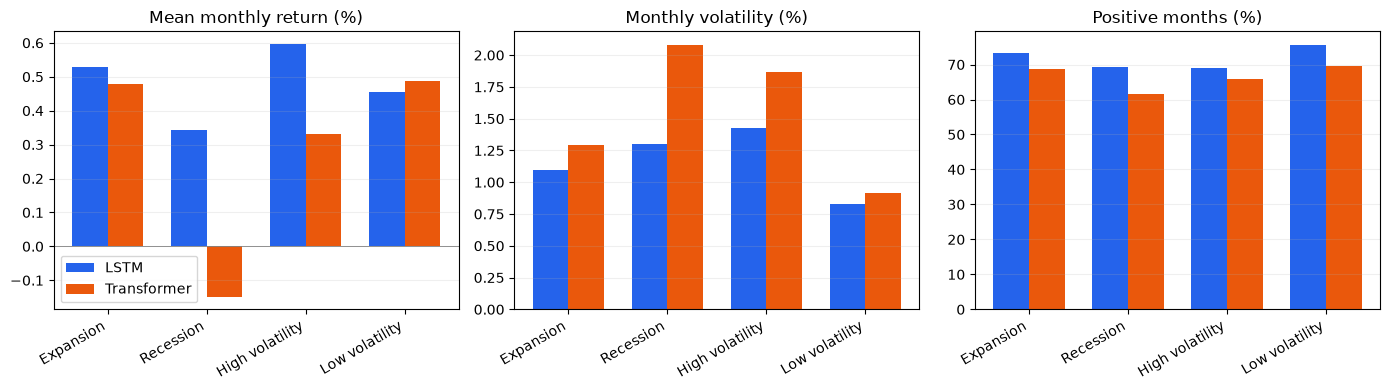

### What regime Sharpe means

Each conditional Sharpe uses only the monthly returns carrying that regime label. It divides their mean by their standard deviation (ddof=0). These months can be separated in time: they are not a continuous holding period. Conditional annualized Sharpe is monthly Sharpe × √12 for scale comparison, not a simulated regime-timing return.

The return/risk table and figure help explain whether a Sharpe gap accompanies weaker average returns, greater volatility, or both. Positive-month frequency adds another view, but a model can win frequently and still lose money through a few large losses. The minimum monthly return describes one observed extreme, not an estimated future risk limit.

Business-cycle labels divide the 300 test months into 274 expansion months and only 26 recession months. Volatility labels form a separate partition; business-cycle and volatility rows must not be added together. Recession estimates have a much smaller sample, so differences should not be treated as equally precise across groups.

NBER recession labels are retrospective. Volatility labels use lagged market volatility and a training-calibrated threshold. Neither model's own volatility determines the market regimes. Joint regime tables provide additional context but can have even smaller samples.

The paper's 0.750 full-test GAN Sharpe is an unconditional benchmark, not a recession or high-volatility Sharpe. A valid paper-regime comparison requires the authors' monthly return series and identical labels. These results explain where our reduced-schedule models differ; they do not establish causality or a trading rule.


1649

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd()
if not (ROOT / 'results').exists(): ROOT = ROOT.parent
assert (ROOT / 'results').exists()
def mdtable(df):
    d=df.copy()
    for col in d.select_dtypes(include='number'): d[col]=d[col].map(lambda x: f'{x:.3f}')
    return '| '+' | '.join(map(str,d.columns))+' |\n| '+' | '.join(['---']*len(d.columns))+' |\n'+'\n'.join('| '+' | '.join(map(str,row))+' |' for row in d.itertuples(index=False,name=None))

out=ROOT/'results/regime_analysis'
reg=pd.read_csv(out/'tables/regime_performance_all_models.csv')
pair=reg[reg.model.isin(['GAN–LSTM reduced schedule','GAN–Transformer reduced schedule'])].copy()
p=pair.pivot(index=['family','regime','months'],columns='model',values='monthly_sharpe').reset_index()
p.columns=['family','regime','months','lstm_monthly_sharpe','transformer_monthly_sharpe']
p['transformer_minus_lstm']=p.transformer_monthly_sharpe-p.lstm_monthly_sharpe
p['share_of_test_months']=p.months/300
p.to_csv(out/'tables/explanation_regime_gaps_and_samples.csv',index=False)
display(Markdown('### Regime comparison with sample sizes\n\n'+mdtable(p)))
risk=pair[['regime','model','months','mean_monthly','volatility_monthly','annualized_sharpe','minimum_month','positive_month_fraction']].copy()
risk.to_csv(out/'tables/explanation_regime_return_risk.csv',index=False)
display(Markdown('### Separate returns from risk\n\n'+mdtable(risk)))
fig,axes=plt.subplots(1,3,figsize=(14,4))
order=['Expansion','Recession','High volatility','Low volatility']
for ax,metric,title in zip(axes,['mean_monthly','volatility_monthly','positive_month_fraction'],['Mean monthly return (%)','Monthly volatility (%)','Positive months (%)']):
    for offset,model,color,label in [(-.18,'GAN–LSTM reduced schedule','#2563eb','LSTM'),(.18,'GAN–Transformer reduced schedule','#ea580c','Transformer')]:
        vals=pair[pair.model==model].set_index('regime').loc[order,metric]*100
        ax.bar(np.arange(4)+offset,vals,width=.36,color=color,label=label)
    ax.set_xticks(np.arange(4),order,rotation=30,ha='right');ax.set_title(title);ax.axhline(0,color='grey',linewidth=.6);ax.grid(axis='y',alpha=.2)
axes[0].legend();fig.tight_layout();fig.savefig(out/'figures/explanation_regime_return_risk.png',dpi=160);plt.show()
text='''### What regime Sharpe means

Each conditional Sharpe uses only the monthly returns carrying that regime label. It divides their mean by their standard deviation (ddof=0). These months can be separated in time: they are not a continuous holding period. Conditional annualized Sharpe is monthly Sharpe × √12 for scale comparison, not a simulated regime-timing return.

The return/risk table and figure help explain whether a Sharpe gap accompanies weaker average returns, greater volatility, or both. Positive-month frequency adds another view, but a model can win frequently and still lose money through a few large losses. The minimum monthly return describes one observed extreme, not an estimated future risk limit.

Business-cycle labels divide the 300 test months into 274 expansion months and only 26 recession months. Volatility labels form a separate partition; business-cycle and volatility rows must not be added together. Recession estimates have a much smaller sample, so differences should not be treated as equally precise across groups.

NBER recession labels are retrospective. Volatility labels use lagged market volatility and a training-calibrated threshold. Neither model's own volatility determines the market regimes. Joint regime tables provide additional context but can have even smaller samples.

The paper's 0.750 full-test GAN Sharpe is an unconditional benchmark, not a recession or high-volatility Sharpe. A valid paper-regime comparison requires the authors' monthly return series and identical labels. These results explain where our reduced-schedule models differ; they do not establish causality or a trading rule.
'''
display(Markdown(text));(out/'explanation_addendum.md').write_text(text)


In [5]:

OUT=ROOT/'results/consolidated_comparison'
lstm='GAN–LSTM reduced schedule';transformer='GAN–Transformer reduced schedule'
best=sharpe.idxmax()
answers=f"""## Results and answers

**Q1 — Paper:** Best local test model is **{best}**, monthly Sharpe **{sharpe[best]:.3f}**, compared with the paper GAN benchmark **0.750**. The earlier GAN replication achieves **{sharpe['GAN–LSTM original']:.3f}**. Training budgets, framework, and tuning differ, so gaps cannot be assigned to one cause.

**Q2 — Architecture:** New LSTM test Sharpe is **{sharpe[lstm]:.3f}** and Transformer is **{sharpe[transformer]:.3f}**. The difference (Transformer minus LSTM) is **{sharpe[transformer]-sharpe[lstm]:.3f}**. This reduced-budget comparison favors LSTM; it does not predict the ordering after full training.

**Q3 — Stability:** LSTM has higher mean rolling Sharpe for both 36- and 60-month windows, and higher conditional Sharpe in all four regime groups. Seed pairs show initialization sensitivity on the same market history. Overlapping windows and shared market observations are not independent replications. Recession results have only 26 observations.

**Q4 — Explanation:** The return/risk tables separate mean returns from volatility. Ensemble Sharpe is not the average member Sharpe because raw weights are averaged before normalization. Paper full-period Sharpe is not a paper rolling or regime benchmark. Use the three diagnostic sections to explain where differences occur without claiming causality.

**Relationship to preceding codes:** Code 07 supplies the original replication, Code 08 supplies the matched architecture experiment, Code 09 supplies time variation, and Code 10 supplies economic-state associations. Code 11 brings them into one reviewable report. Full training, original-author return comparisons, and transaction-cost analysis require separate experiments.
"""
display(Markdown(answers));(OUT/'results_and_answers.md').write_text(answers)
risk=pd.read_csv(OUT/'tables/all_models_test_risk.csv')
assert len(comparison)==10 and len(risk)==6
assert np.isfinite(risk.select_dtypes(include='number').to_numpy()).all()
print('Code 11 verified: six return series, paper benchmarks, risk diagnostics, and expanded comparisons.')


## Results and answers

**Q1 — Paper:** Best local test model is **GAN–LSTM original**, monthly Sharpe **0.612**, compared with the paper GAN benchmark **0.750**. The earlier GAN replication achieves **0.612**. Training budgets, framework, and tuning differ, so gaps cannot be assigned to one cause.

**Q2 — Architecture:** New LSTM test Sharpe is **0.459** and Transformer is **0.304**. The difference (Transformer minus LSTM) is **-0.155**. This reduced-budget comparison favors LSTM; it does not predict the ordering after full training.

**Q3 — Stability:** LSTM has higher mean rolling Sharpe for both 36- and 60-month windows, and higher conditional Sharpe in all four regime groups. Seed pairs show initialization sensitivity on the same market history. Overlapping windows and shared market observations are not independent replications. Recession results have only 26 observations.

**Q4 — Explanation:** The return/risk tables separate mean returns from volatility. Ensemble Sharpe is not the average member Sharpe because raw weights are averaged before normalization. Paper full-period Sharpe is not a paper rolling or regime benchmark. Use the three diagnostic sections to explain where differences occur without claiming causality.

**Relationship to preceding codes:** Code 07 supplies the original replication, Code 08 supplies the matched architecture experiment, Code 09 supplies time variation, and Code 10 supplies economic-state associations. Code 11 brings them into one reviewable report. Full training, original-author return comparisons, and transaction-cost analysis require separate experiments.


Code 11 verified: six return series, paper benchmarks, risk diagnostics, and expanded comparisons.


## Results and answers

**Q1 — Paper:** Best local test model is **GAN–LSTM original**, monthly Sharpe **0.612**, compared with the paper GAN benchmark **0.750**. The earlier GAN replication achieves **0.612**. Training budgets, framework, and tuning differ, so gaps cannot be assigned to one cause.

**Q2 — Architecture:** New LSTM test Sharpe is **0.459** and Transformer is **0.304**. The difference (Transformer minus LSTM) is **-0.155**. This reduced-budget comparison favors LSTM; it does not predict the ordering after full training.

**Q3 — Stability:** LSTM has higher mean rolling Sharpe for both 36- and 60-month windows, and higher conditional Sharpe in all four regime groups. Seed pairs show initialization sensitivity on the same market history. Overlapping windows and shared market observations are not independent replications. Recession results have only 26 observations.

**Q4 — Explanation:** The return/risk tables separate mean returns from volatility. Ensemble Sharpe is not the average member Sharpe because raw weights are averaged before normalization. Paper full-period Sharpe is not a paper rolling or regime benchmark. Use the three diagnostic sections to explain where differences occur without claiming causality.

**Relationship to preceding codes:** Code 07 supplies the original replication, Code 08 supplies the matched architecture experiment, Code 09 supplies time variation, and Code 10 supplies economic-state associations. Code 11 brings them into one reviewable report. Full training, original-author return comparisons, and transaction-cost analysis require separate experiments.


## 5. Architecture × rolling window × economic regime

We add an endpoint-regime analysis of completed windows and an illustrative fixed 50/50 return blend. Read the definitions carefully: these are distinct from conditional-month Sharpe and from rolling retraining.

### Architecture and fixed 50/50 return blend: all sample splits

| split | model | months | mean_monthly | volatility_monthly | monthly_sharpe | annualized_sharpe |
| --- | --- | --- | --- | --- | --- | --- |
| train | LSTM | 240.000 | 0.012 | 0.009 | 1.308 | 4.530 |
| train | Transformer | 240.000 | 0.010 | 0.009 | 1.049 | 3.634 |
| train | 50/50 blend | 240.000 | 0.011 | 0.008 | 1.414 | 4.900 |
| validation | LSTM | 60.000 | 0.005 | 0.007 | 0.750 | 2.599 |
| validation | Transformer | 60.000 | 0.006 | 0.010 | 0.589 | 2.039 |
| validation | 50/50 blend | 60.000 | 0.006 | 0.006 | 0.915 | 3.171 |
| test | LSTM | 300.000 | 0.005 | 0.011 | 0.459 | 1.591 |
| test | Transformer | 300.000 | 0.004 | 0.014 | 0.304 | 1.055 |
| test | 50/50 blend | 300.000 | 0.005 | 0.010 | 0.463 | 1.604 |

### Architecture and blend: conditional monthly Sharpe

| regime | model | months | monthly_sharpe |
| --- | --- | --- | --- |
| Expansion | LSTM | 274.000 | 0.483 |
| Expansion | Transformer | 274.000 | 0.369 |
| Expansion | 50/50 blend | 274.000 | 0.517 |
| Recession | LSTM | 26.000 | 0.264 |
| Recession | Transformer | 26.000 | -0.071 |
| Recession | 50/50 blend | 26.000 | 0.076 |
| High volatility | LSTM | 123.000 | 0.417 |
| High volatility | Transformer | 123.000 | 0.177 |
| High volatility | 50/50 blend | 123.000 | 0.345 |
| Low volatility | LSTM | 177.000 | 0.549 |
| Low volatility | Transformer | 177.000 | 0.531 |
| Low volatility | 50/50 blend | 177.000 | 0.684 |

### Combined analysis: rolling Sharpe grouped by the endpoint regime

| window_months | family | endpoint_regime | windows | lstm_mean_annualized_sharpe | transformer_mean_annualized_sharpe | blend_mean_annualized_sharpe | transformer_minus_lstm_mean | transformer_higher_fraction | blend_higher_than_lstm_fraction |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 36.000 | business_cycle | Expansion | 239.000 | 2.058 | 1.473 | 2.191 | -0.584 | 0.351 | 0.498 |
| 36.000 | business_cycle | Recession | 26.000 | 1.383 | 1.409 | 1.941 | 0.027 | 0.500 | 0.692 |
| 36.000 | volatility | High volatility | 117.000 | 1.642 | 0.893 | 1.489 | -0.749 | 0.205 | 0.376 |
| 36.000 | volatility | Low volatility | 148.000 | 2.268 | 1.921 | 2.701 | -0.347 | 0.493 | 0.628 |
| 60.000 | business_cycle | Expansion | 215.000 | 1.783 | 1.162 | 1.799 | -0.621 | 0.167 | 0.484 |
| 60.000 | business_cycle | Recession | 26.000 | 1.893 | 1.775 | 2.469 | -0.118 | 0.462 | 0.846 |
| 60.000 | volatility | High volatility | 117.000 | 1.722 | 1.042 | 1.658 | -0.680 | 0.111 | 0.436 |
| 60.000 | volatility | Low volatility | 124.000 | 1.863 | 1.404 | 2.072 | -0.459 | 0.282 | 0.605 |

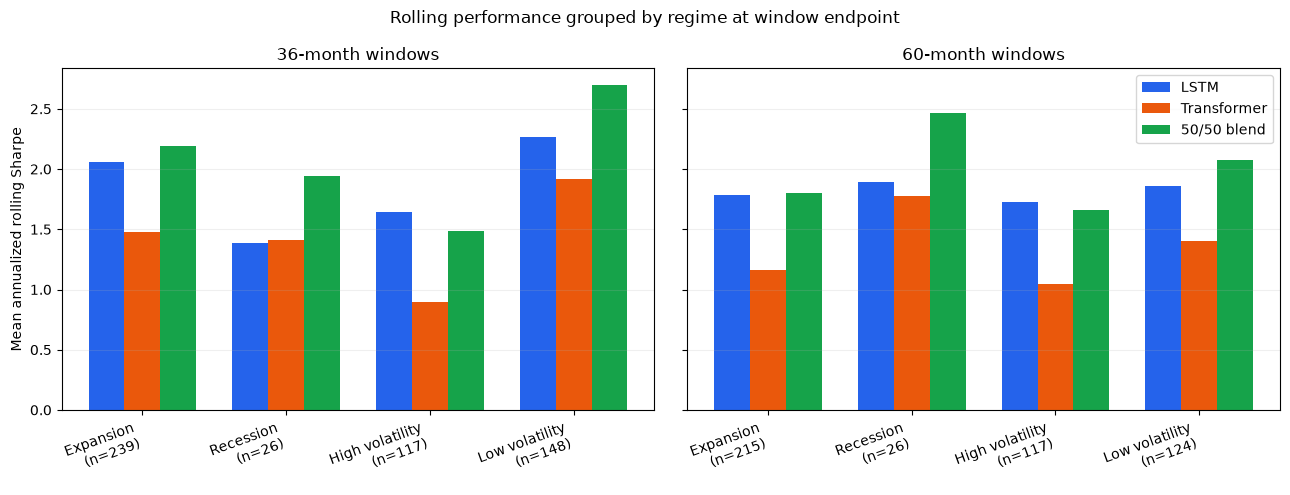

## Combined-analysis interpretation

The fixed 50/50 return blend has full-test monthly Sharpe **0.463**, compared with LSTM **0.459** and Transformer **0.304**. The blend averages the two saved portfolio returns with constant weights; no blend weights are selected by test performance. It is an additional descriptive illustration created after examining the test outcomes, not a newly validated out-of-sample strategy or a new trained model. It differs from the within-architecture raw-stock-weight ensemble and has no additional gross-exposure renormalization.

The combined table groups each completed rolling window by the regime in its **ending month**. For example, a 36-month window ending in a recession can include expansion months. These means describe trailing performance observed at different endpoint states; they are not Sharpes computed solely from recession returns. The earlier conditional-regime table answers the latter question.

Each business-cycle partition and volatility partition is separate. Window counts overlap and are not independent observations. The endpoint classification is descriptive; NBER recession dates are retrospective. Volatility labels are lagged and training calibrated. No regime selects a different model or triggers a trading switch.

Together the analyses answer four different questions: architecture comparison asks which fixed model performs better overall; rolling evaluation asks when performance changes; conditional regimes ask how returns differ across labeled months; rolling-by-regime asks what trailing performance looks like at different economic endpoints. The fixed blend asks whether simple return averaging adds descriptive diversification value.


Combined comparisons verified and saved; no models retrained.


In [1]:

from pathlib import Path
import json,hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown,display
ROOT=Path.cwd()
if not (ROOT/'results').exists(): ROOT=ROOT.parent
OUT=ROOT/'results/consolidated_comparison'
R08=ROOT/'results/paper_matched_reduced_schedule';R09=ROOT/'results/rolling_oos_reduced_schedule';R10=ROOT/'results/regime_analysis'
def mt(d):
    d=d.copy()
    for c in d.select_dtypes(include='number'):d[c]=d[c].map(lambda v:f'{v:.3f}')
    return '| '+' | '.join(map(str,d.columns))+' |\n| '+' | '.join(['---']*len(d.columns))+' |\n'+'\n'.join('| '+' | '.join(map(str,r))+' |' for r in d.itertuples(index=False,name=None))
all_factors=pd.read_csv(R08/'factors/transformer_lstm_comparison.csv',parse_dates=['date']).set_index('date')
labels=pd.read_csv(R10/'tables/monthly_regime_labels.csv',parse_dates=['date']).set_index('date')
factors=all_factors[['split','gan_lstm_matched','gan_transformer']].rename(columns={'gan_lstm_matched':'LSTM','gan_transformer':'Transformer'})
factors['50/50 blend']=.5*factors.LSTM+.5*factors.Transformer
assert len(factors)==600 and factors.index.is_unique
np.testing.assert_allclose(factors['50/50 blend'],(factors.LSTM+factors.Transformer)/2)
assert np.isfinite(factors[['LSTM','Transformer','50/50 blend']].to_numpy()).all()
test=factors[factors.split=='test'].drop(columns='split')
assert test.index.equals(labels.index) and len(test)==300
joined=test.join(labels,validate='one_to_one');assert not joined.isna().any().any()
def metrics(v):
    sd=v.std(ddof=0);s=v.mean()/sd if sd>0 else np.nan
    return dict(months=len(v),mean_monthly=v.mean(),volatility_monthly=sd,monthly_sharpe=s,annualized_sharpe=s*np.sqrt(12))
rows=[]
for split,g in factors.groupby('split',sort=False):
    for model in ['LSTM','Transformer','50/50 blend']:rows.append(dict(split=split,model=model,**metrics(g[model])))
blend_split=pd.DataFrame(rows);blend_split.to_csv(OUT/'tables/architecture_blend_split_comparison.csv',index=False)
display(Markdown('### Architecture and fixed 50/50 return blend: all sample splits\n\n'+mt(blend_split)))
regrows=[]
for family,col in [('business_cycle','business_cycle'),('volatility','volatility_regime')]:
    for regime,g in joined.groupby(col):
        for model in test.columns:regrows.append(dict(family=family,regime=regime,model=model,**metrics(g[model])))
blend_reg=pd.DataFrame(regrows);blend_reg.to_csv(OUT/'tables/architecture_blend_regime_comparison.csv',index=False)
display(Markdown('### Architecture and blend: conditional monthly Sharpe\n\n'+mt(blend_reg[['regime','model','months','monthly_sharpe']])))
rolling_parts=[];combined=[];rollsummary=[]
for window in [36,60]:
    rolling=test.rolling(window,min_periods=window).mean()/test.rolling(window,min_periods=window).std(ddof=0)*np.sqrt(12)
    complete=rolling.dropna().join(labels[['business_cycle','volatility_regime']],validate='one_to_one')
    assert len(complete)==300-window+1
    for model in test.columns:rollsummary.append(dict(window_months=window,model=model,complete_windows=len(complete),mean_annualized_sharpe=complete[model].mean(),median_annualized_sharpe=complete[model].median()))
    complete['transformer_minus_lstm']=complete.Transformer-complete.LSTM
    complete['blend_minus_lstm']=complete['50/50 blend']-complete.LSTM
    for family,col in [('business_cycle','business_cycle'),('volatility','volatility_regime')]:
        for regime,g in complete.groupby(col):
            combined.append(dict(window_months=window,family=family,endpoint_regime=regime,windows=len(g),lstm_mean_annualized_sharpe=g.LSTM.mean(),transformer_mean_annualized_sharpe=g.Transformer.mean(),blend_mean_annualized_sharpe=g['50/50 blend'].mean(),transformer_minus_lstm_mean=g.transformer_minus_lstm.mean(),transformer_higher_fraction=(g.transformer_minus_lstm>0).mean(),blend_higher_than_lstm_fraction=(g.blend_minus_lstm>0).mean()))
    rolling_parts.append(complete.reset_index().assign(window_months=window))
combined=pd.DataFrame(combined);rollsummary=pd.DataFrame(rollsummary)
combined.to_csv(OUT/'tables/rolling_by_endpoint_regime.csv',index=False)
rollsummary.to_csv(OUT/'tables/architecture_blend_rolling_summary.csv',index=False)
pd.concat(rolling_parts).to_csv(OUT/'tables/architecture_blend_rolling_series.csv',index=False)
factors.to_csv(OUT/'tables/architecture_blend_monthly_returns.csv')
display(Markdown('### Combined analysis: rolling Sharpe grouped by the endpoint regime\n\n'+mt(combined)))
# Check the weighted group means recover the corresponding overall rolling mean.
for (window,family),g in combined.groupby(['window_months','family']):
    for model,col in [('LSTM','lstm_mean_annualized_sharpe'),('Transformer','transformer_mean_annualized_sharpe'),('50/50 blend','blend_mean_annualized_sharpe')]:
        expected=rollsummary[(rollsummary.window_months==window)&(rollsummary.model==model)].mean_annualized_sharpe.iloc[0]
        np.testing.assert_allclose(np.average(g[col],weights=g.windows),expected,rtol=1e-12,atol=1e-12)
# Confirm our recomputed rolling pair matches Code 09.
old=pd.read_csv(R09/'tables/rolling_metrics.csv',parse_dates=['date'])
new=pd.concat(rolling_parts)
for name,model in [('gan_lstm_matched','LSTM'),('gan_transformer','Transformer')]:
    a=old[old.model==name].dropna(subset=['sharpe_annualized']).set_index(['window_months','date']).sharpe_annualized.sort_index()
    b=new.set_index(['window_months','date'])[model].sort_index()
    np.testing.assert_allclose(a,b,rtol=1e-10,atol=1e-10)
fig,axes=plt.subplots(1,2,figsize=(13,5),sharey=True)
order=['Expansion','Recession','High volatility','Low volatility']
for ax,window in zip(axes,[36,60]):
    z=combined[combined.window_months==window].set_index('endpoint_regime').loc[order]
    x=np.arange(4)
    for offset,col,color,name in [(-.25,'lstm_mean_annualized_sharpe','#2563eb','LSTM'),(0,'transformer_mean_annualized_sharpe','#ea580c','Transformer'),(.25,'blend_mean_annualized_sharpe','#16a34a','50/50 blend')]:
        ax.bar(x+offset,z[col],width=.25,color=color,label=name)
    ax.set_xticks(x,[f'{r}\n(n={int(z.loc[r,"windows"])})' for r in order],rotation=20,ha='right');ax.set_title(f'{window}-month windows');ax.axhline(0,color='grey',linewidth=.5);ax.grid(axis='y',alpha=.2)
axes[0].set_ylabel('Mean annualized rolling Sharpe');axes[1].legend();fig.suptitle('Rolling performance grouped by regime at window endpoint');fig.tight_layout();fig.savefig(OUT/'figures/rolling_by_endpoint_regime.png',dpi=160);plt.show()
perf=blend_split[blend_split.split=='test'].set_index('model')
text=f'''## Combined-analysis interpretation

The fixed 50/50 return blend has full-test monthly Sharpe **{perf.loc['50/50 blend','monthly_sharpe']:.3f}**, compared with LSTM **{perf.loc['LSTM','monthly_sharpe']:.3f}** and Transformer **{perf.loc['Transformer','monthly_sharpe']:.3f}**. The blend averages the two saved portfolio returns with constant weights; no blend weights are selected by test performance. It is an additional descriptive illustration created after examining the test outcomes, not a newly validated out-of-sample strategy or a new trained model. It differs from the within-architecture raw-stock-weight ensemble and has no additional gross-exposure renormalization.

The combined table groups each completed rolling window by the regime in its **ending month**. For example, a 36-month window ending in a recession can include expansion months. These means describe trailing performance observed at different endpoint states; they are not Sharpes computed solely from recession returns. The earlier conditional-regime table answers the latter question.

Each business-cycle partition and volatility partition is separate. Window counts overlap and are not independent observations. The endpoint classification is descriptive; NBER recession dates are retrospective. Volatility labels are lagged and training calibrated. No regime selects a different model or triggers a trading switch.

Together the analyses answer four different questions: architecture comparison asks which fixed model performs better overall; rolling evaluation asks when performance changes; conditional regimes ask how returns differ across labeled months; rolling-by-regime asks what trailing performance looks like at different economic endpoints. The fixed blend asks whether simple return averaging adds descriptive diversification value.
'''
display(Markdown(text));(OUT/'combined_analysis_answers.md').write_text(text)
assert len(blend_split)==9 and len(blend_reg)==12 and len(combined)==8 and len(rollsummary)==6
print('Combined comparisons verified and saved; no models retrained.')


## Combined-analysis interpretation

The fixed 50/50 return blend has full-test monthly Sharpe **0.463**, compared with LSTM **0.459** and Transformer **0.304**. The blend averages the two saved portfolio returns with constant weights; no blend weights are selected by test performance. It is an additional descriptive illustration created after examining the test outcomes, not a newly validated out-of-sample strategy or a new trained model. It differs from the within-architecture raw-stock-weight ensemble and has no additional gross-exposure renormalization.

The combined table groups each completed rolling window by the regime in its **ending month**. For example, a 36-month window ending in a recession can include expansion months. These means describe trailing performance observed at different endpoint states; they are not Sharpes computed solely from recession returns. The earlier conditional-regime table answers the latter question.

Each business-cycle partition and volatility partition is separate. Window counts overlap and are not independent observations. The endpoint classification is descriptive; NBER recession dates are retrospective. Volatility labels are lagged and training calibrated. No regime selects a different model or triggers a trading switch.

Together the analyses answer four different questions: architecture comparison asks which fixed model performs better overall; rolling evaluation asks when performance changes; conditional regimes ask how returns differ across labeled months; rolling-by-regime asks what trailing performance looks like at different economic endpoints. The fixed blend asks whether simple return averaging adds descriptive diversification value.
